# IMPORT

In [1]:
from google.colab import drive
drive.mount("/content/mount")

Mounted at /content/mount


In [2]:
# install Hangul font

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 6 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (32.2 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and direct

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

plt.rc('font', family='NanumBarunGothic')
df=pd.read_csv("/content/태림_통합데이터3.csv")

# 다시 EDA

In [4]:
MONTH_MAP = {
    'January':1,'February':2,'March':3,'April':4,
    'May':5,'June':6,'July':7,'August':8,
    'September':9,'October':10,'November':11,'December':12
}

df['Month_Num']    = df['Month'].map(MONTH_MAP)
df['Release_Date'] = pd.to_datetime(df['ID_Release'].str[:8], format='%Y%m%d', errors='coerce')
df['Target_Date']  = pd.to_datetime(
    dict(year=df['Year'], month=df['Month_Num'], day=df['Day']), errors='coerce'
)
df['Lead_Days'] = (df['Target_Date'] - df['Release_Date']).dt.days

PN_LIST = df['ZF_PN'].value_counts().index.tolist()
print(f"ZF_PN 목록: {PN_LIST}")
print(f"전체 레코드: {len(df):,}건")
df.head(3)


ZF_PN 목록: ['A0070270', 'A0049000', 'A0028219', 'A0067885', 'A021N565', 'A0030814X']
전체 레코드: 31,238건


,ZF_PN,Supplier_PN,Order,ID_Release,Month,Year,Day,Quantity,UN,Firm/Forecast,Shipping_Inst,Shipped_Invoice,CUM_QTY,Month_Num,Release_Date,Target_Date,Lead_Days
0,A0028219,A0028219,PO348384,20240521-004,April,2024,4,6.4,pc,FIRM,SEA,ZFB240314572,1.656.750,4,2024-05-21,2024-04-04,-47
1,A0028219,A0028219,PO348384,20240521-004,April,2024,4,6.4,pc,FIRM,SEA,ZFB240329575,1.656.750,4,2024-05-21,2024-04-04,-47
2,A0028219,A0028219,PO348384,20240521-004,April,2024,4,6.4,pc,FIRM,SEA,ZFB240405576,1.656.750,4,2024-05-21,2024-04-04,-47


In [6]:
rows = []
for pn in PN_LIST:
    g = df[df['ZF_PN'] == pn]
    firm  = g[g['Firm/Forecast'] == 'FIRM']
    fc    = g[g['Firm/Forecast'] == 'FORECAST']
    ld    = firm['Lead_Days']
    rows.append({
        'ZF_PN'          : pn,
        '총 레코드'       : len(g),
        'FIRM 건수'       : len(firm),
        'FIRM 비율(%)'    : round(len(firm)/len(g)*100, 1),
        'FORECAST 건수'   : len(fc),
        'Release 수'      : g['ID_Release'].nunique(),
        'FIRM Lead 평균'  : round(ld.mean(), 1),
        'FIRM Lead 중앙값': round(ld.median(), 1),
        'FIRM Lead 75%'  : round(ld.quantile(.75), 1),
        '평균 Qty'        : round(g['Quantity'].mean(), 2),
    })

summary = pd.DataFrame(rows).set_index('ZF_PN')
print("=" * 60)
print("품번별 요약 통계")
print("=" * 60)
print(summary.to_string())

품번별 요약 통계
           총 레코드  FIRM 건수  FIRM 비율(%)  FORECAST 건수  Release 수  FIRM Lead 평균  FIRM Lead 중앙값  FIRM Lead 75%  평균 Qty
ZF_PN                                                                                                            
A0070270    6514      733        11.3         5781         77         -29.3          -33.0           -6.0    8.70
A0049000    5914      862        14.6         5052         77         -22.2          -24.0            4.0   25.95
A0028219    5720      873        15.3         4847         77         -24.9          -28.0            2.0    5.08
A0067885    5298      729        13.8         4569         77         -25.8          -29.0            0.0    9.58
A021N565    5067      625        12.3         4442         77         -19.5          -24.0            7.0    6.62
A0030814X   2725      565        20.7         2160         77         -24.7          -28.0            2.0    3.58


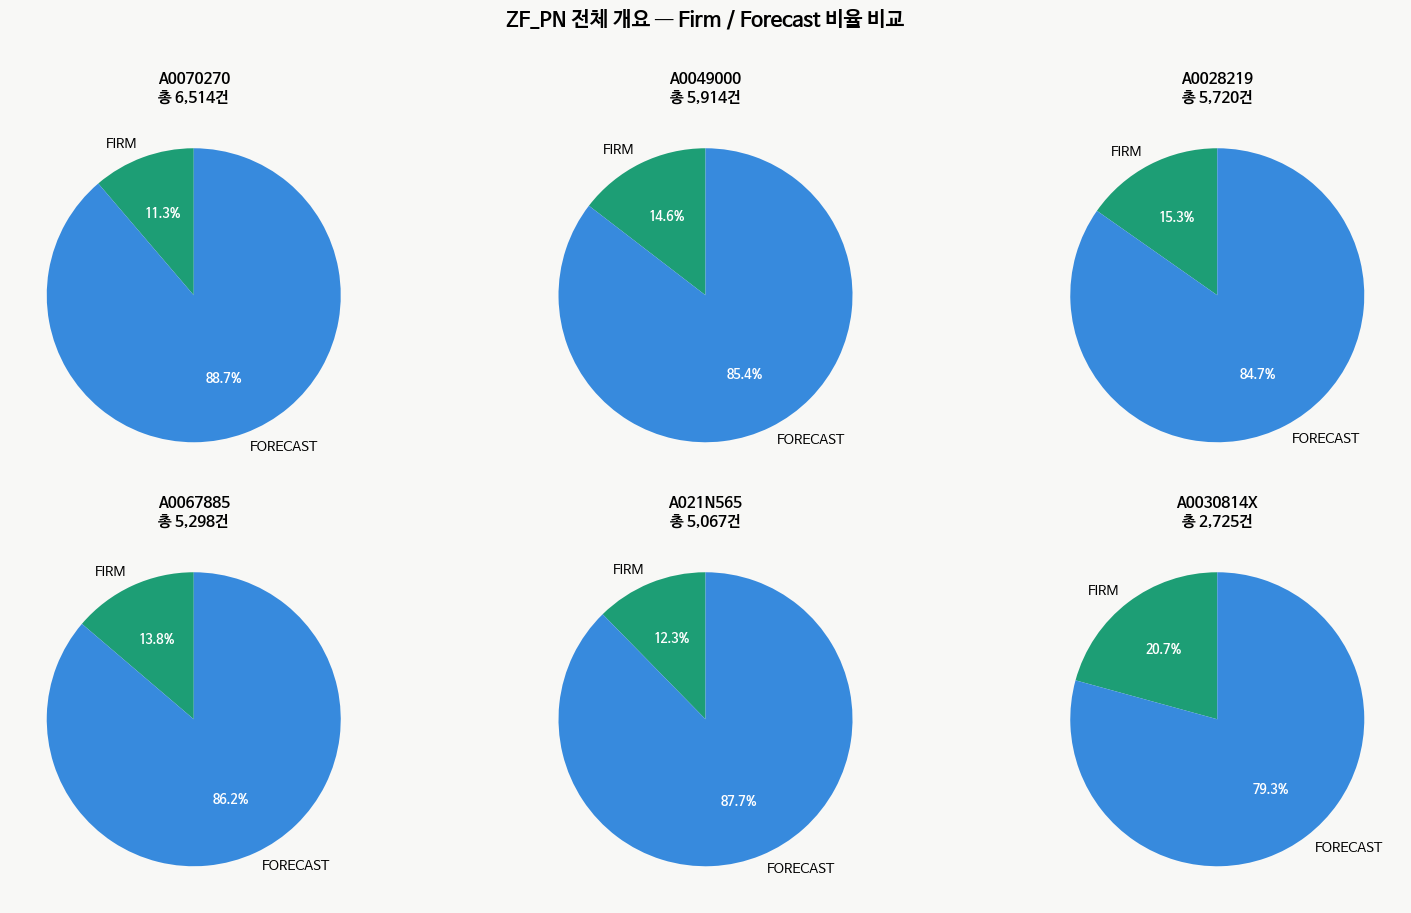

In [7]:
COLORS = {
    'FIRM'    : '#1D9E75',
    'FORECAST': '#378ADD',
    'firm2'   : '#7F77DD',
    'bg'      : '#F8F8F6',
    'line'    : '#E0E0DC',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('ZF_PN 전체 개요 — Firm / Forecast 비율 비교', fontsize=15, fontweight='bold', y=1.01)

for ax, pn in zip(axes.flat, PN_LIST):
    g     = df[df['ZF_PN'] == pn]
    firm  = (g['Firm/Forecast'] == 'FIRM').sum()
    fc    = (g['Firm/Forecast'] == 'FORECAST').sum()
    total = len(g)

    ax.set_facecolor(COLORS['bg'])
    wedges, texts, autotexts = ax.pie(
        [firm, fc],
        labels=['FIRM', 'FORECAST'],
        colors=[COLORS['FIRM'], COLORS['FORECAST']],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(linewidth=0),
        textprops=dict(fontsize=10),
    )
    for at in autotexts:
        at.set_fontsize(9)
        at.set_fontweight('bold')
        at.set_color('white')

    ax.set_title(f'{pn}\n총 {total:,}건', fontsize=11, fontweight='bold', pad=8)

plt.tight_layout()
plt.savefig('01_overall_pie.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

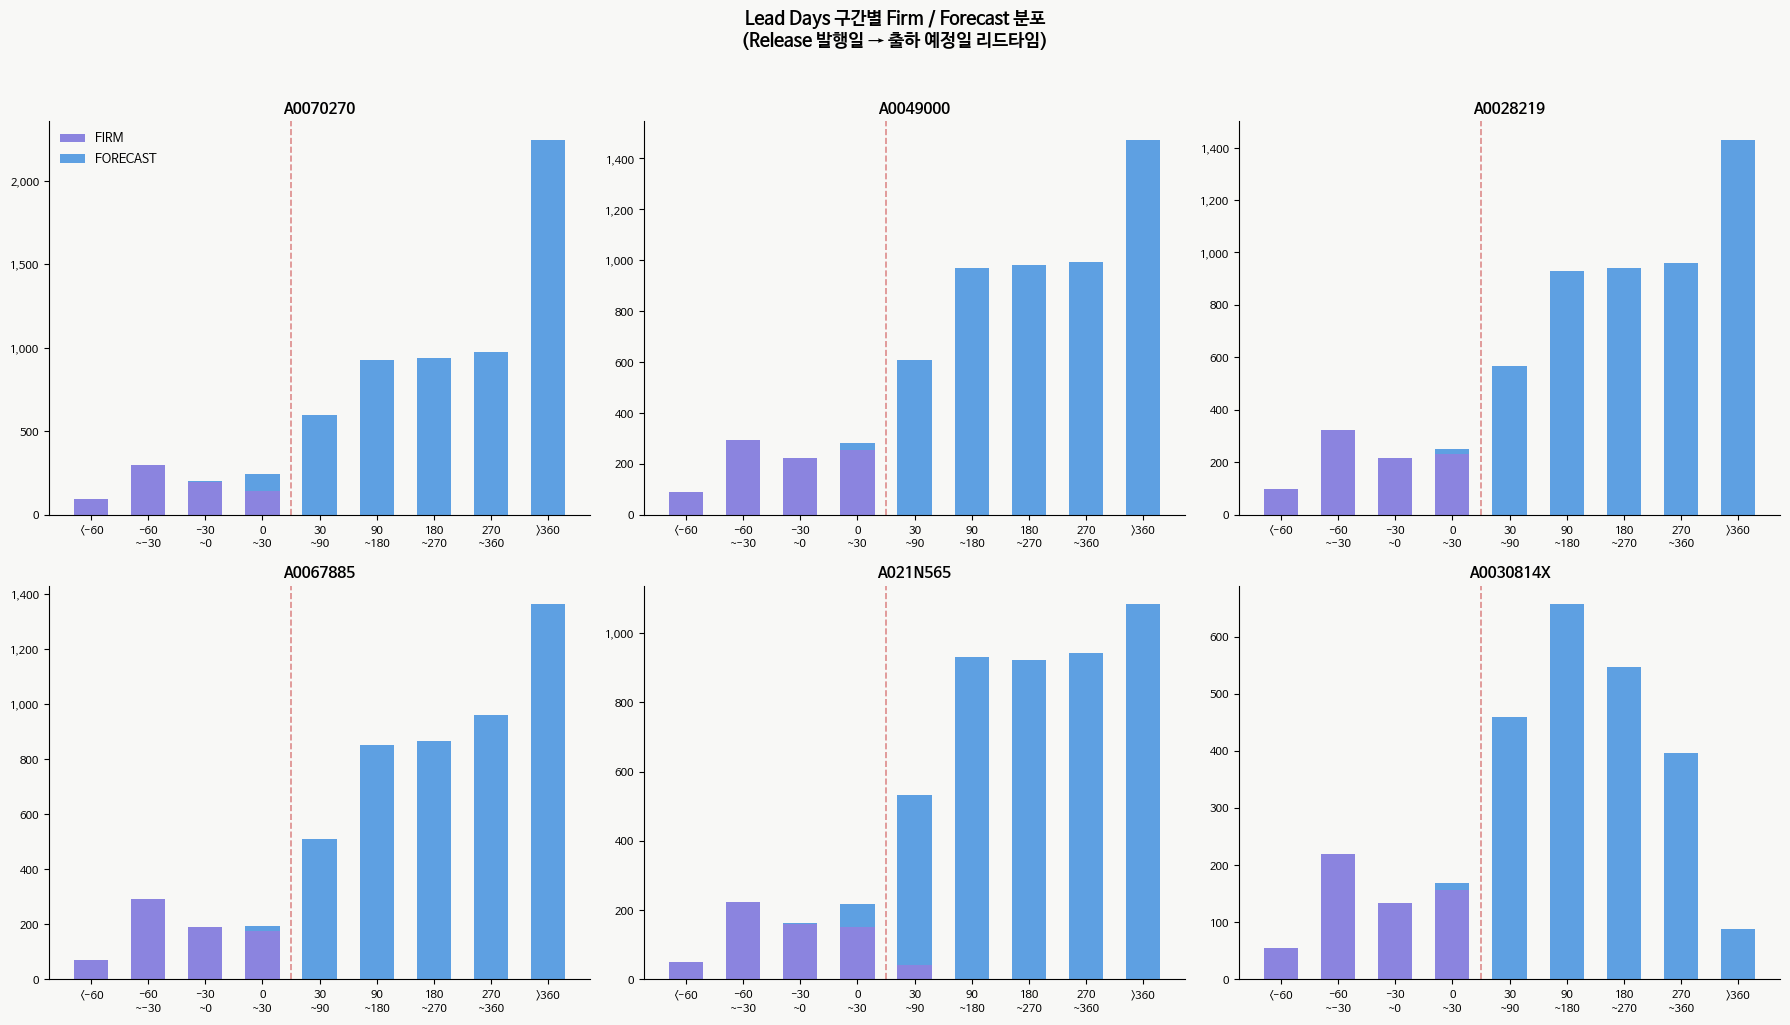

In [8]:
bins   = [-float('inf'), -60, -30, 0, 30, 90, 180, 270, 360, float('inf')]
labels = ['<-60','-60\n~-30','-30\n~0','0\n~30','30\n~90','90\n~180','180\n~270','270\n~360','>360']

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=False)
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('Lead Days 구간별 Firm / Forecast 분포\n(Release 발행일 → 출하 예정일 리드타임)', fontsize=13, fontweight='bold', y=1.02)

for ax, pn in zip(axes.flat, PN_LIST):
    g = df[df['ZF_PN'] == pn].copy()
    g['Lead_Bin'] = pd.cut(g['Lead_Days'], bins=bins, labels=labels)

    pivot = (g.groupby(['Lead_Bin', 'Firm/Forecast'], observed=True)
              .size().unstack(fill_value=0))
    if 'FIRM' not in pivot.columns:
        pivot['FIRM'] = 0
    if 'FORECAST' not in pivot.columns:
        pivot['FORECAST'] = 0

    x = range(len(labels))
    ax.set_facecolor(COLORS['bg'])
    ax.bar(x, pivot.get('FIRM', [0]*9),     color=COLORS['firm2'],   label='FIRM',     alpha=0.9, width=0.6)
    ax.bar(x, pivot.get('FORECAST', [0]*9), color=COLORS['FORECAST'], label='FORECAST', alpha=0.8, width=0.6,
           bottom=pivot.get('FIRM', [0]*9))

    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(f'{pn}', fontsize=11, fontweight='bold')
    ax.set_facecolor(COLORS['bg'])
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(labelsize=8)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{int(v):,}'))
    if ax == axes.flat[0]:
        ax.legend(fontsize=9, framealpha=0)

    # FIRM/FORECAST 경계 수직선
    ax.axvline(x=3.5, color='#CC4444', linewidth=1.2, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('02_lead_days_dist.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

- FORECAST(파란색) 는 납기 30일 이상 먼 구간(30~90, 90~180, 180~270, 270~360, >360)에 압도적으로 몰려 있습니다. 특히 >360일 구간이 가장 많은데, 이는 1년 이상 먼 납기를 미리 예측해서 발행한 발주가 대부분이라는 의미입니다.
- FIRM(보라색) 은 점선(0일) 왼쪽, 즉 -60일 ~ 0일 구간에만 존재합니다. 출하일이 가까워진 시점에서만 FIRM으로 확정된다는 뜻입니다.
- 0~30일 구간에서만 FIRM과 FORECAST가 겹칩니다. 이 구간이 바로 전환이 일어나는 핵심 구간입니다

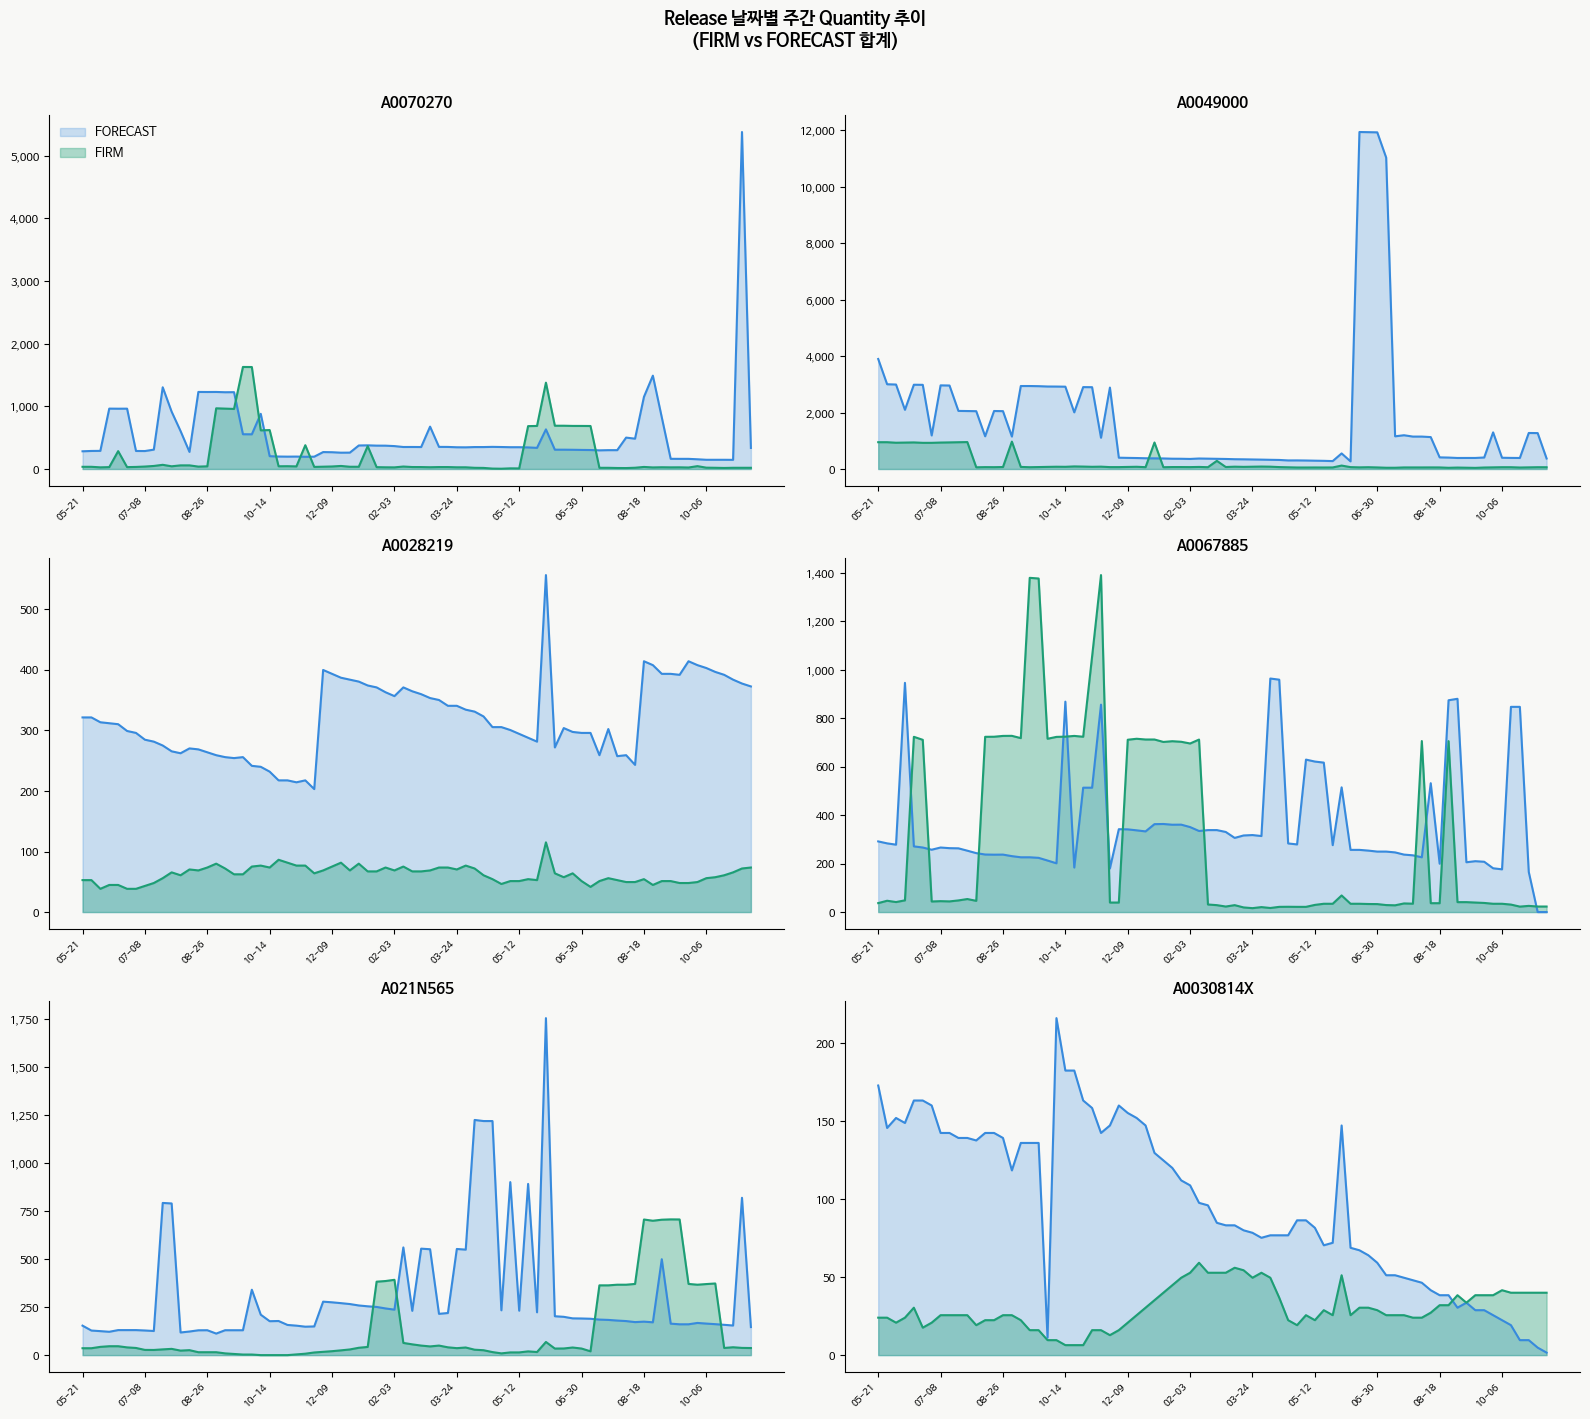

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=False)
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('Release 날짜별 주간 Quantity 추이\n(FIRM vs FORECAST 합계)', fontsize=13, fontweight='bold', y=1.01)

for ax, pn in zip(axes.flat, PN_LIST):
    g = df[df['ZF_PN'] == pn]
    weekly = (g.groupby(['Release_Date', 'Firm/Forecast'])['Quantity']
               .sum().unstack(fill_value=0).sort_index())

    firm_vals = weekly.get('FIRM', pd.Series(dtype=float))
    fc_vals   = weekly.get('FORECAST', pd.Series(dtype=float))
    x = range(len(weekly))

    ax.set_facecolor(COLORS['bg'])
    ax.fill_between(x, fc_vals.values,   color=COLORS['FORECAST'], alpha=0.25, label='FORECAST')
    ax.plot        (x, fc_vals.values,   color=COLORS['FORECAST'], linewidth=1.5)
    ax.fill_between(x, firm_vals.values, color=COLORS['FIRM'],     alpha=0.35, label='FIRM')
    ax.plot        (x, firm_vals.values, color=COLORS['FIRM'],     linewidth=1.5)

    # x축 레이블: 10개만 표시
    step = max(1, len(weekly) // 10)
    tick_pos   = list(range(0, len(weekly), step))
    tick_labels= [str(d.date())[5:] for d in weekly.index[tick_pos]]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels, fontsize=7, rotation=45, ha='right')

    ax.set_title(f'{pn}', fontsize=11, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{int(v):,}'))
    ax.tick_params(axis='y', labelsize=8)
    if ax == axes.flat[0]:
        ax.legend(fontsize=9, framealpha=0)

plt.tight_layout()
plt.savefig('03_qty_trend.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

- A0028219: FORECAST가 꾸준히 300 수준을 유지하다 완만하게 감소. FIRM은 낮고 안정적입니다.
- A0049000: 가장 수량이 크고(최대 12,000), 중간에 급격한 스파이크가 있습니다. 대량 일괄 발주가 간헐적으로 발생하는 품번입니다.
- A0067885: FIRM(초록)이 FORECAST(파란)를 역전하는 구간이 여러 번 나타납니다. FIRM 발주가 불규칙하게 대량으로 들어오는 특이한 패턴입니다.
- A0070270: 후반부(2025년 10~11월)에 FORECAST가 5,000까지 급등합니다. 미래 대량 예측 발주가 몰린 것입니다.
- A021N565: 중간 구간(2025년 3~6월)에 Qty가 급등했다가 감소. 수요 변동이 큰 품번입니다.
- A0030814X: 전체적으로 수량이 가장 작고(최대 200), FIRM이 점진적으로 증가하는 안정적인 패턴입니다.

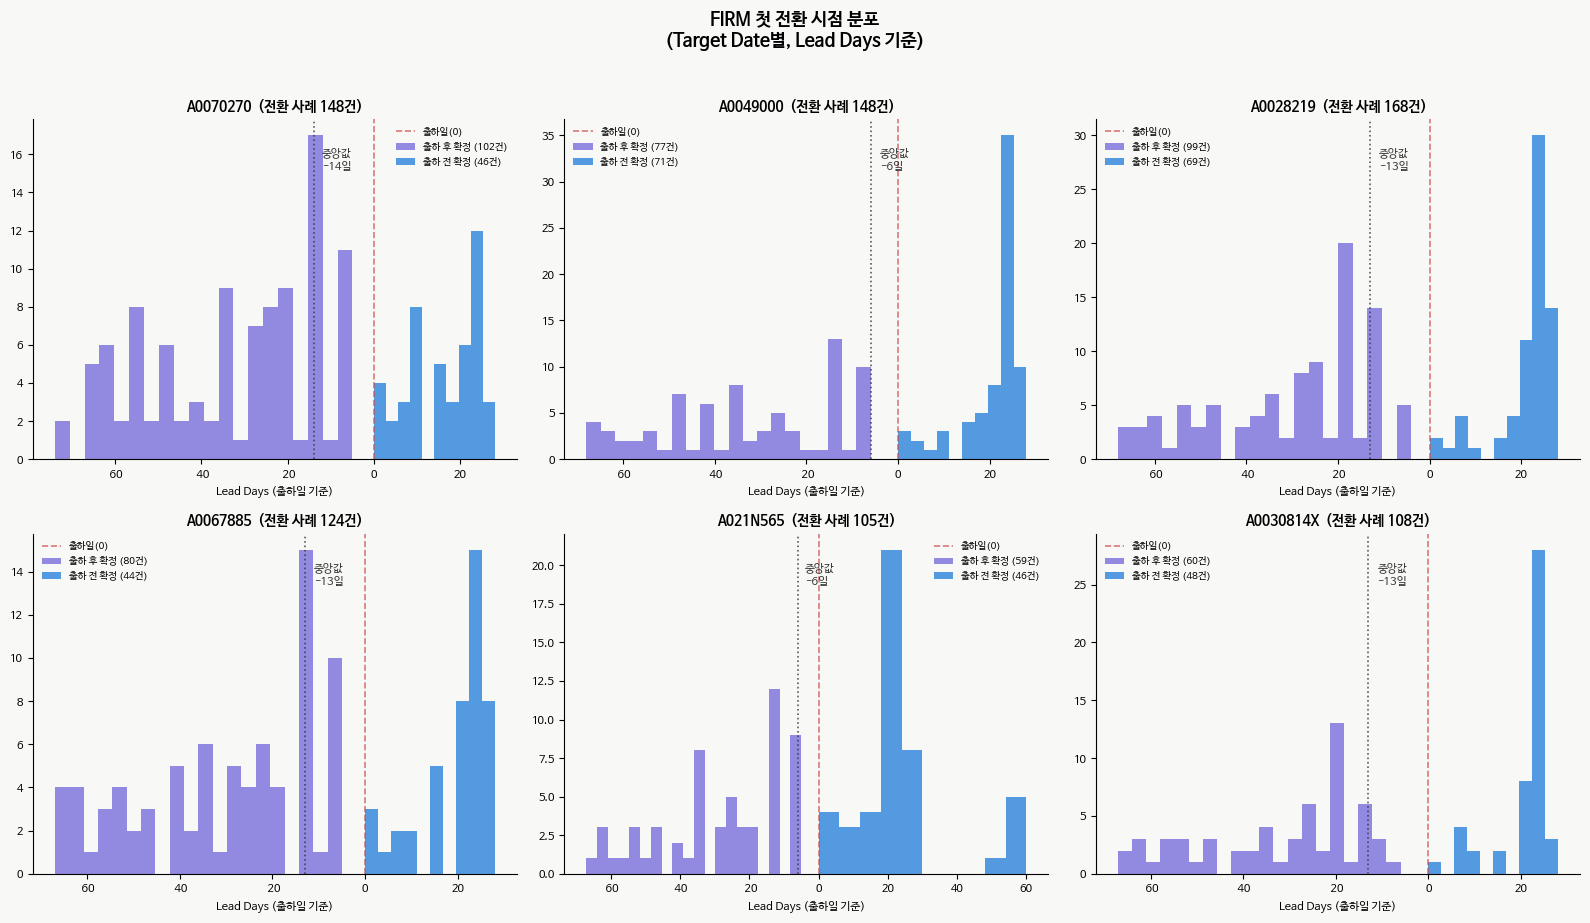

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('FIRM 첫 전환 시점 분포\n(Target Date별, Lead Days 기준)', fontsize=13, fontweight='bold', y=1.02)

for ax, pn in zip(axes.flat, PN_LIST):
    g = df[df['ZF_PN'] == pn]
    firm_targets = g[g['Firm/Forecast'] == 'FIRM']['Target_Date'].unique()

    transitions = []
    for td in firm_targets:
        sub  = g[g['Target_Date'] == td]
        firm = sub[sub['Firm/Forecast'] == 'FIRM']
        fc   = sub[sub['Firm/Forecast'] == 'FORECAST']
        if len(firm) > 0 and len(fc) > 0:
            first_firm_lead = firm.loc[firm['Release_Date'].idxmin(), 'Lead_Days']
            transitions.append(first_firm_lead)

    transitions = pd.Series(transitions).dropna()

    ax.set_facecolor(COLORS['bg'])
    ax.axvline(0, color='#CC4444', linewidth=1.2, linestyle='--', alpha=0.7, label='출하일(0)')

    neg = transitions[transitions < 0]
    pos = transitions[transitions >= 0]
    ax.hist(neg, bins=20, color=COLORS['firm2'],   alpha=0.85, label=f'출하 후 확정 ({len(neg)}건)')
    ax.hist(pos, bins=10, color=COLORS['FORECAST'], alpha=0.85, label=f'출하 전 확정 ({len(pos)}건)')

    med = transitions.median()
    ax.axvline(med, color='#333', linewidth=1.2, linestyle=':', alpha=0.8)
    ax.text(med + 2, ax.get_ylim()[1] * 0.85, f'중앙값\n{med:.0f}일',
            fontsize=8, color='#333')

    ax.set_title(f'{pn}  (전환 사례 {len(transitions)}건)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Lead Days (출하일 기준)', fontsize=8)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7, framealpha=0)

plt.tight_layout()
plt.savefig('04_firm_transition.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

- Lead_Days = Target_Date(Month + Year + Day) - Release_Date(ID_Release 앞 8자리)
- D_Release (20240521-004) → 작업한 날짜 (발주서 발행일)
Month + Year + Day → 출하 예정일 (그 발주서에 적힌 납기일)

그러니까 Lead Days는 "이 발주서를 작성한 날로부터 납기일까지 며칠 남았냐" 입니다.
예시로 보면:
ID_Release   = 20240521-004  →  작업일: 2024년 5월 21일
Month/Year/Day = June / 2025 / 16  →  납기일: 2025년 6월 16일

Lead_Days = 2025-06-16 - 2024-05-21 = +391일
→ 이 발주서는 납기 391일 전에 작성된 FORECAST
ID_Release   = 20250609-004  →  작업일: 2025년 6월 9일
Month/Year/Day = June / 2025 / 16  →  납기일: 2025년 6월 16일

Lead_Days = 2025-06-16 - 2025-06-09 = +7일
→ 납기 7일 전에 FIRM으로 확정

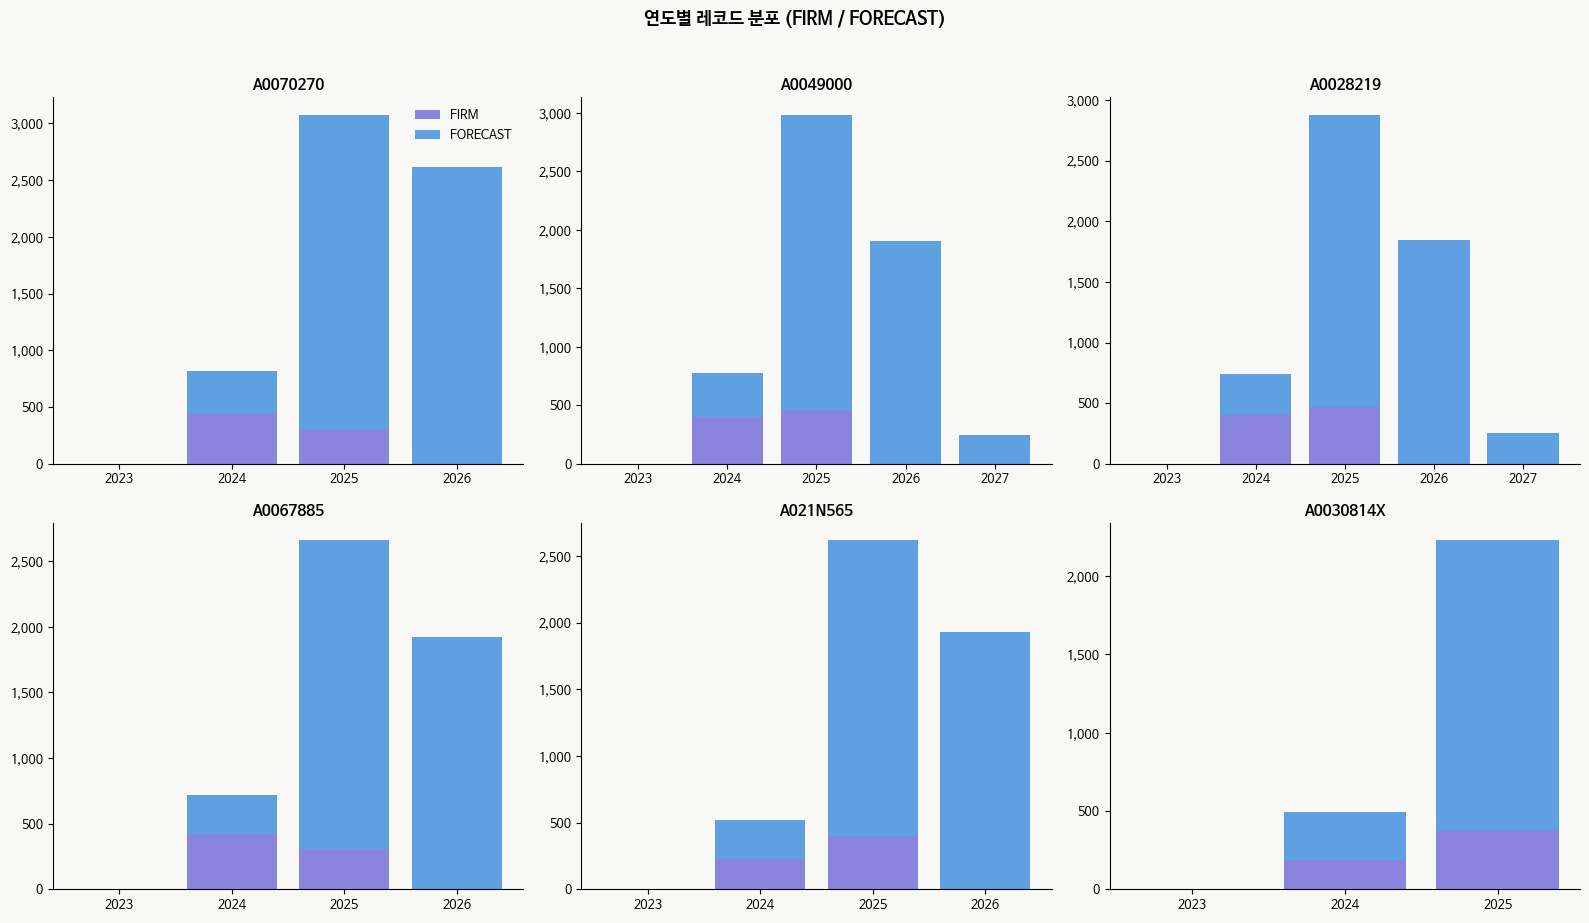

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('연도별 레코드 분포 (FIRM / FORECAST)', fontsize=13, fontweight='bold', y=1.02)

for ax, pn in zip(axes.flat, PN_LIST):
    g     = df[df['ZF_PN'] == pn]
    pivot = (g.groupby(['Year', 'Firm/Forecast'])
              .size().unstack(fill_value=0).sort_index())

    years     = [str(y) for y in pivot.index]
    firm_vals = pivot.get('FIRM', [0]*len(pivot))
    fc_vals   = pivot.get('FORECAST', [0]*len(pivot))

    ax.set_facecolor(COLORS['bg'])
    ax.bar(years, firm_vals, color=COLORS['firm2'],    label='FIRM',     alpha=0.9)
    ax.bar(years, fc_vals,   color=COLORS['FORECAST'], label='FORECAST', alpha=0.8,
           bottom=firm_vals)

    ax.set_title(f'{pn}', fontsize=11, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(labelsize=9)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{int(v):,}'))
    if ax == axes.flat[0]:
        ax.legend(fontsize=9, framealpha=0)

plt.tight_layout()
plt.savefig('05_yearly_dist.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()


- FIRM(보라색) 은 2024년과 2025년 초반에만 집중되어 있습니다. 이미 출하가 임박하거나 완료된 기간이기 때문
- FORECAST(파란색) 는 2025~2026년에 대량으로 쌓여 있습니다. 아직 출하일이 먼 미래 예측
- A0030814X 는 2025년까지만 데이터가 있어 다른 품번보다 기간이 짧다.
- A0049000, A0028219 는 2027년까지 FORECAST 데이터가 있어 장기 수요 계획이 가장 길게 잡혀 있는 품번
- 2026년 이후는 100% FORECAST로만 구성되어 있는데, 이는 당연히 아직 납기가 먼 미래이기 때문에 FIRM으로 전환되지 않은 상태

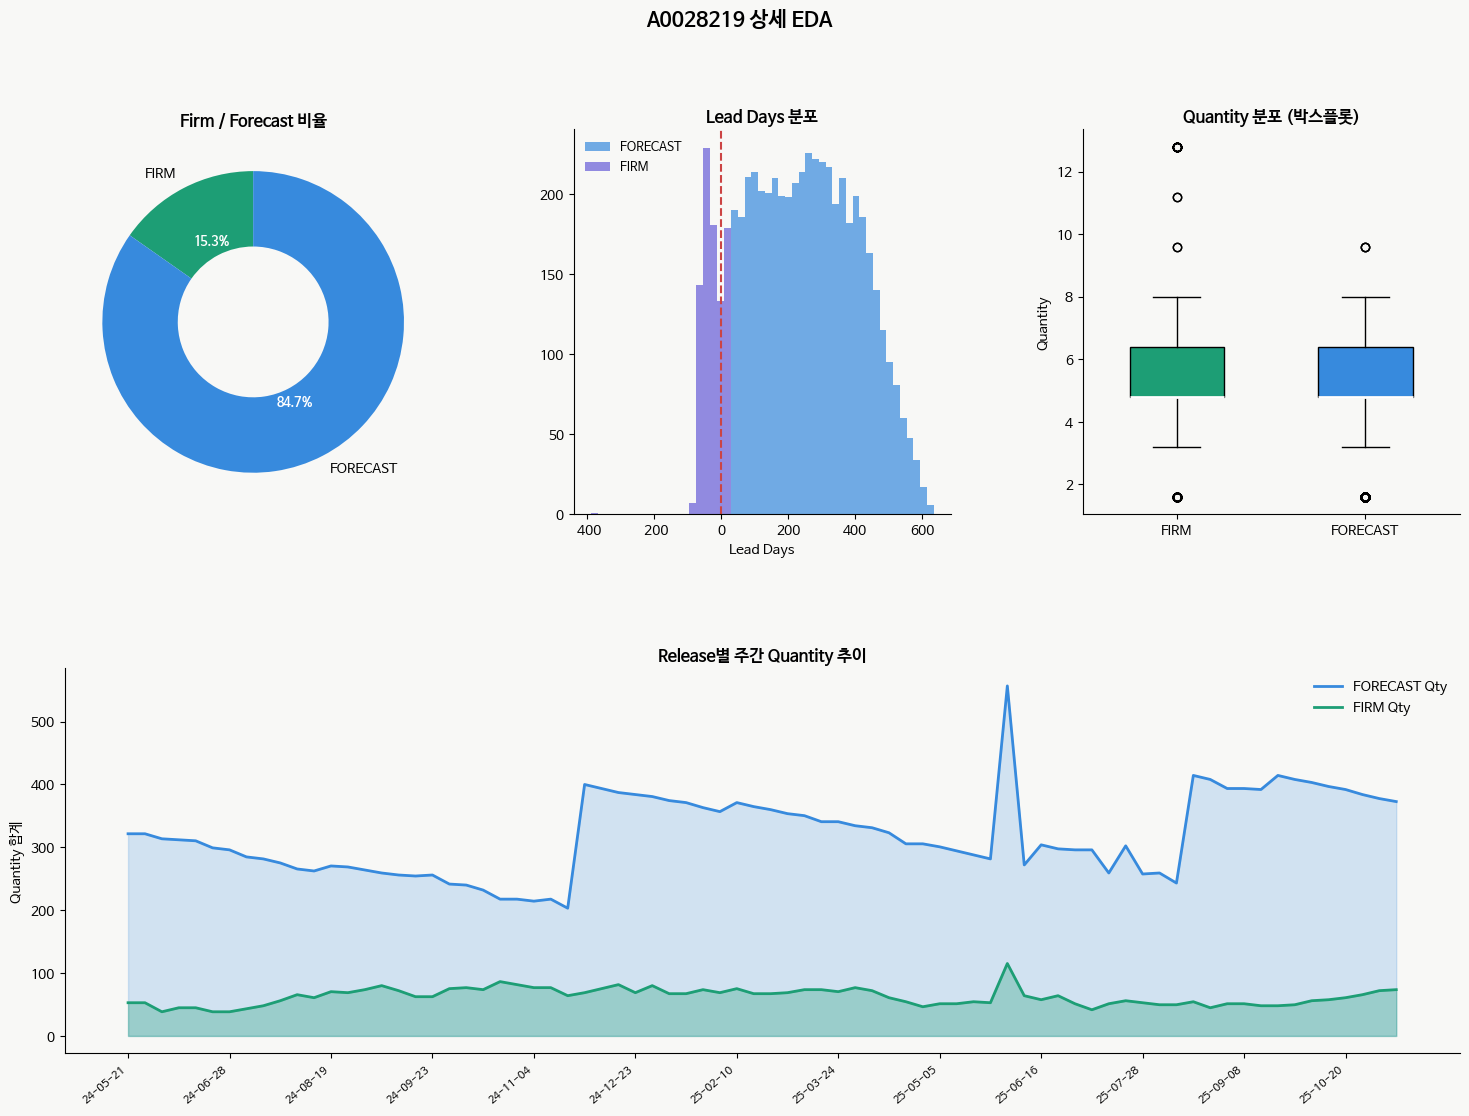

In [12]:
TARGET_PN = 'A0028219'   # ← 여기서 품번 변경 가능

g = df[df['ZF_PN'] == TARGET_PN].copy()

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle(f'{TARGET_PN} 상세 EDA', fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# (1) Donut
ax1 = fig.add_subplot(gs[0, 0])
firm_n = (g['Firm/Forecast'] == 'FIRM').sum()
fc_n   = (g['Firm/Forecast'] == 'FORECAST').sum()
ax1.set_facecolor(COLORS['bg'])
wedges, _, autotexts = ax1.pie(
    [firm_n, fc_n], labels=['FIRM','FORECAST'],
    colors=[COLORS['FIRM'], COLORS['FORECAST']],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(linewidth=0, width=0.5),
    textprops=dict(fontsize=10),
)
for at in autotexts:
    at.set_fontsize(9); at.set_fontweight('bold'); at.set_color('white')
ax1.set_title('Firm / Forecast 비율', fontweight='bold')

# (2) Lead Days 히스토그램
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(COLORS['bg'])
firm_ld = g[g['Firm/Forecast'] == 'FIRM']['Lead_Days'].dropna()
fc_ld   = g[g['Firm/Forecast'] == 'FORECAST']['Lead_Days'].dropna()
ax2.hist(fc_ld,   bins=30, color=COLORS['FORECAST'], alpha=0.7, label='FORECAST')
ax2.hist(firm_ld, bins=20, color=COLORS['firm2'],    alpha=0.85, label='FIRM')
ax2.axvline(0, color='#CC4444', linewidth=1.5, linestyle='--')
ax2.set_xlabel('Lead Days')
ax2.set_title('Lead Days 분포', fontweight='bold')
ax2.spines[['top','right']].set_visible(False)
ax2.legend(fontsize=9, framealpha=0)

# (3) Qty 박스플롯
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor(COLORS['bg'])
data_firm = g[g['Firm/Forecast'] == 'FIRM']['Quantity'].dropna()
data_fc   = g[g['Firm/Forecast'] == 'FORECAST']['Quantity'].dropna()
bp = ax3.boxplot([data_firm, data_fc], labels=['FIRM','FORECAST'],
                 patch_artist=True, widths=0.5,
                 medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor(COLORS['FIRM'])
bp['boxes'][1].set_facecolor(COLORS['FORECAST'])
ax3.set_title('Quantity 분포 (박스플롯)', fontweight='bold')
ax3.set_ylabel('Quantity')
ax3.spines[['top','right']].set_visible(False)

# (4) Release별 Qty 추이 (하단 전체 너비)
ax4 = fig.add_subplot(gs[1, :])
ax4.set_facecolor(COLORS['bg'])
weekly = (g.groupby(['Release_Date', 'Firm/Forecast'])['Quantity']
           .sum().unstack(fill_value=0).sort_index())
x = range(len(weekly))
fv = weekly.get('FIRM',     pd.Series(dtype=float))
cv = weekly.get('FORECAST', pd.Series(dtype=float))
ax4.fill_between(x, cv.values, color=COLORS['FORECAST'], alpha=0.2)
ax4.plot(x, cv.values, color=COLORS['FORECAST'], linewidth=2, label='FORECAST Qty')
ax4.fill_between(x, fv.values, color=COLORS['FIRM'],     alpha=0.3)
ax4.plot(x, fv.values, color=COLORS['FIRM'],     linewidth=2, label='FIRM Qty')
step = max(1, len(weekly) // 12)
ax4.set_xticks(list(range(0, len(weekly), step)))
ax4.set_xticklabels(
    [str(d.date())[2:] for d in weekly.index[::step]],
    rotation=40, ha='right', fontsize=8
)
ax4.set_title('Release별 주간 Quantity 추이', fontweight='bold')
ax4.set_ylabel('Quantity 합계')
ax4.spines[['top','right']].set_visible(False)
ax4.legend(fontsize=10, framealpha=0)
ax4.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{int(v):,}'))

fname = f'06_detail_{TARGET_PN}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

- Cell 2전처리 (날짜 파싱, Lead_Days 계산)
- Cell 36개 품번 요약 통계 테이블 출력
- Cell 4전체 개요 — Firm/Forecast 비율 Donut 차트 (6개)
- Cell 5Lead Days 구간별 누적 막대 (6개 비교)
- Cell 6Release별 Qty 추이 라인 차트 (6개)
- Cell 7Firm 첫 전환 시점 히스토그램 (6개)
- Cell 8연도별 누적 막대 (6개 비교)
- Cell 품범 상세 분석 까지